In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy as cp
import scipy
from scipy.sparse import load_npz, dok_array
import math
import csv
from scipy.sparse import csr_matrix
import warnings
import pandas as pd
import sympy
from sympy import symbols, Eq, solve

## Defining universal values

In [2]:
THRES = 30
NUM_STRAINS = 3
NUM_TIMEPOINTS = 6
STRAIN_NAMES = ['yKH88','yFR1','yFR2']


## 1.  PLOT THE READS THAT COME FROM EACH STRAIN

### Importing .npz files as numpy arrays

In [23]:
# Each replicate will be its own tensor of timepoints. ex REP1[0] will return counts for replicate 1 at the first timepoint
# For a given timepoint, there will be two matrices [bcds][counts]

yKH88_npz = ['D765-D566bcd.npz','D766-D567bcd.npz','D767-D568bcd.npz','D768-D569bcd.npz','D769-D570bcd.npz','D770-D571bcd.npz']
yFR1_npz= ['D771-D572bcd.npz','D772-D573bcd.npz','D773-D574bcd.npz','D774-D575bcd.npz','D775-D576bcd.npz','D776-D577bcd.npz']
yFR2_npz = ['D777-D578bcd.npz', 'D778-D579bcd.npz','D779-D580bcd.npz','D780-D581bcd.npz','D781-D582bcd.npz','D782-D583bcd.npz']

yKH88 = [load_npz(name).toarray() for name in yKH88_npz]
yFR1 = [load_npz(name).toarray() for name in yFR1_npz]
yFR2 = [load_npz(name).toarray() for name in yFR2_npz]


STRAINS = [yKH88, yFR1, yFR2]
np.shape(STRAINS)

(3, 6, 16777216, 1)

STRAIN[strain][timepoint][barcode]


## How many barcodes does each strain have? 

In [6]:

print(f"yKH88: has {np.size(np.where(yKH88[0] > THRES))} barcodes with counts  above the {THRES} count threshold")
print(f"yFR1: has {np.size(np.where(yFR1[0] > THRES))} barcodes with counts above the {THRES} count threshold")
print(f"yFR2: has {np.size(np.where(yFR2[0] > THRES))} barcodes with counts above the {THRES} count threshold")



yKH88: has 72735 barcodes with counts  above the 30 count threshold
yFR1: has 99968 barcodes with counts above the 30 count threshold
yFR2: has 47413 barcodes with counts above the 30 count threshold


### For each replicate and timepoint, plot a histogram of all barcodes and their counts

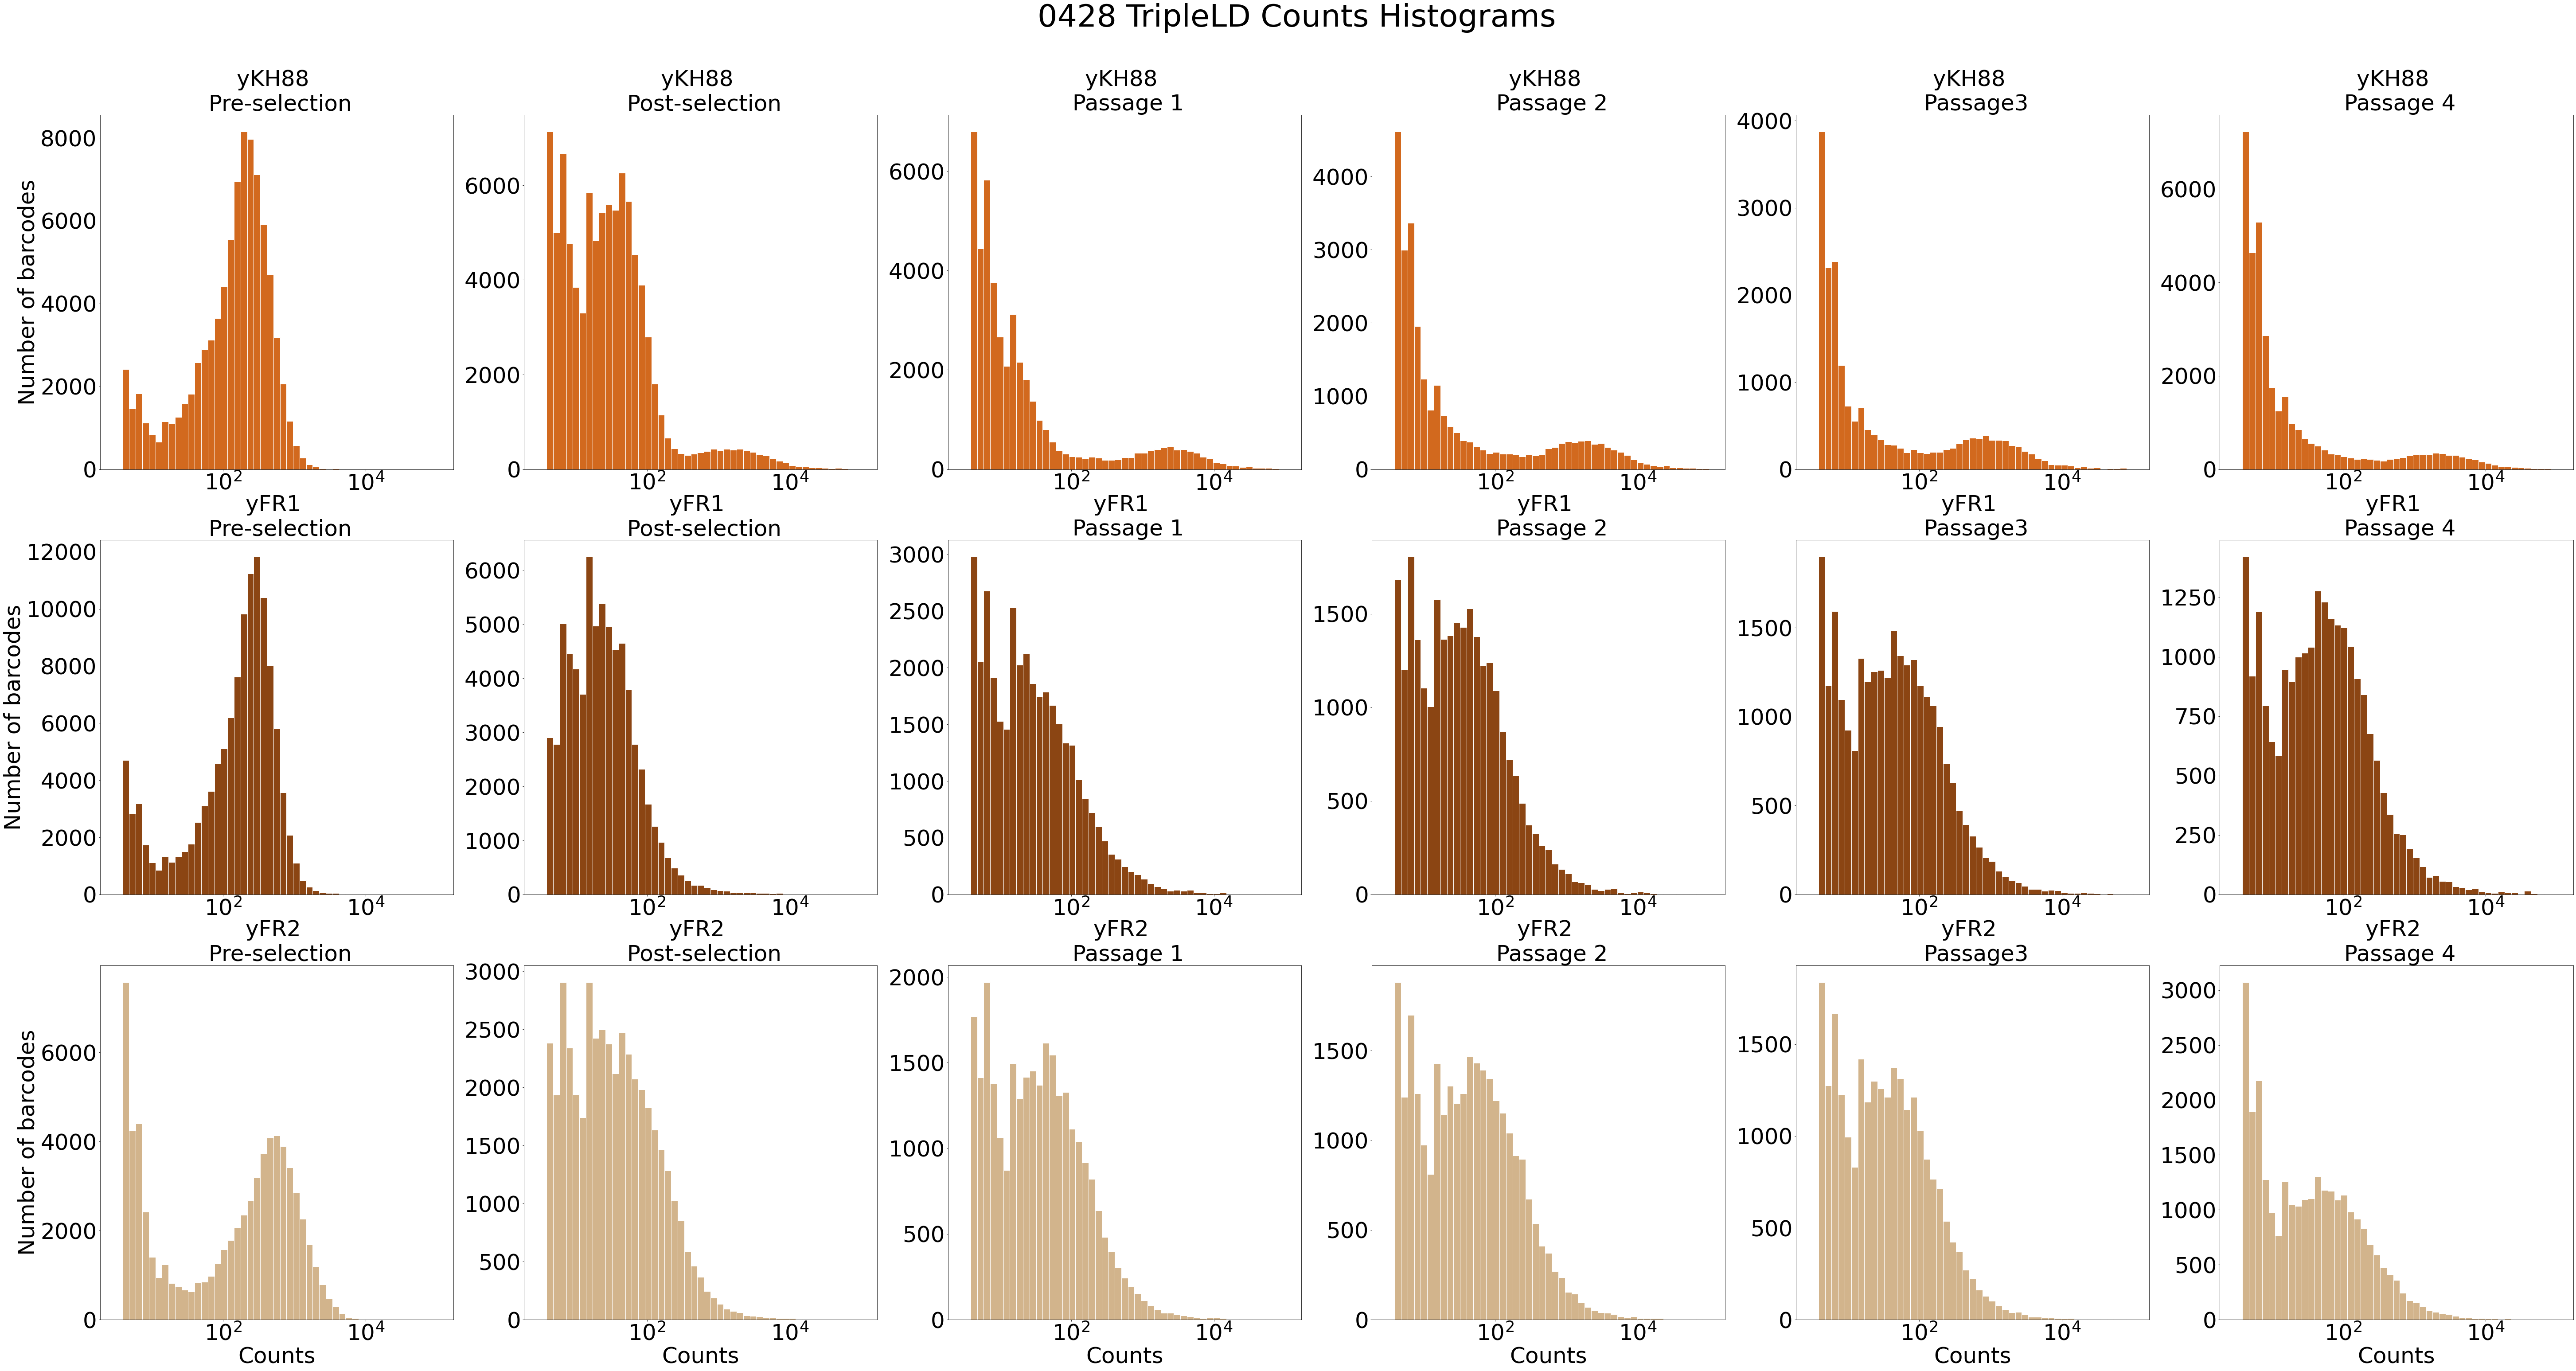

In [7]:
figure, ax = plt.subplots(NUM_STRAINS,NUM_TIMEPOINTS,figsize=(100, 50))
colors = ['Chocolate', 'Saddlebrown','Tan']
times = ['Pre-selection', 'Post-selection', 'Passage 1', 'Passage 2', 'Passage3','Passage 4']

for i in range(NUM_STRAINS):
    for j in range(NUM_TIMEPOINTS):
        
        #choose_rep contains each REP matrix 
        # [i][j][1] --> [which strain?][which timpoint][counts]
        ax[i,j].hist(STRAINS[i][j], bins = np.logspace(0.5,5,50), ec='white',color=colors[i])
       
            
        if i > 1:
            ax[i,j].set_xlabel('Counts', fontsize = 50)
        if j == 0:
            ax[i,j].set_ylabel('Number of barcodes', fontsize = 50)
        
        ax[i,j].set_title(f'{STRAIN_NAMES[i]} \n {times[j]}', fontsize = 50)
        ax[i,j].set_xscale("log")
        #ax[i,j].set_yscale("log")
        
        #ax[i,j].ticklabel_format(axis='both',style = 'sci')
        ax[i,j].tick_params(axis='both', which='major', labelsize=50)
        
        

figure.suptitle("0428 TripleLD Counts Histograms", fontsize=70, y = 0.95)        
#figure.savefig("0428 TripleLD Counts Histograms.pdf", format="pdf")

plt.show()

## 2. Plot the histogram of timepoint 1 and filter out low reads

yKH88: has 72735 barcodes with counts  above the 30 count threshold
yFR1: has 99968 barcodes with counts above the 30 count threshold
yFR2: has 47413 barcodes with counts above the 30 count threshold


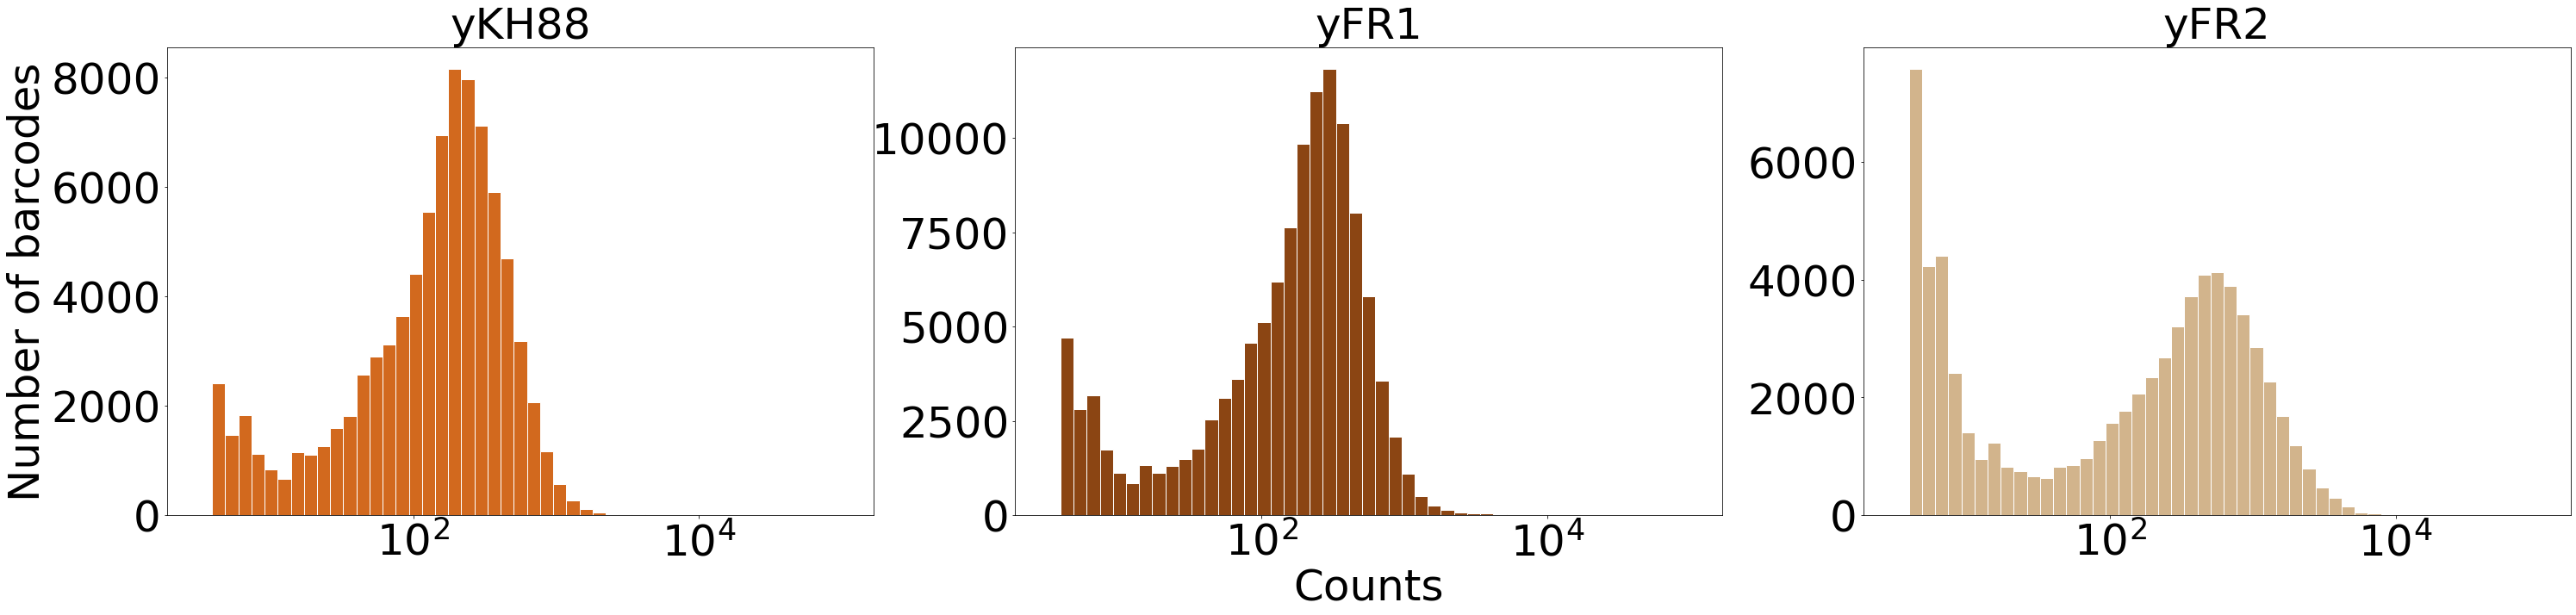

In [8]:
figure, ax = plt.subplots(1,NUM_STRAINS,figsize=(50, 10))
colors = ['Chocolate', 'Saddlebrown','Tan']
times = ['Pre-selection', 'Post-selection', 'Passage 1', 'Passage 2', 'Passage3','Passage 4']

for i in range(NUM_STRAINS):
  

    #choose_rep contains each REP matrix 
    # [i][j][1] --> [which strain?][which timpoint][counts]
    ax[i].hist(STRAINS[i][0], bins = np.logspace(0.5,5,50), ec='white',color=colors[i])


    if i == 1:
        ax[i].set_xlabel('Counts', fontsize = 50)
    if i == 0:
        ax[i].set_ylabel('Number of barcodes', fontsize = 50)

    ax[i].set_title(f'{STRAIN_NAMES[i]}', fontsize = 50)
    #ax[i,j].set_xscale("log")
    #ax[i].set_yscale("log")
    ax[i].set_xscale("log")

    #ax[i,j].ticklabel_format(axis='both',style = 'sci')
    ax[i].tick_params(axis='both', which='major', labelsize=50)
      
    #print(f"{STRAIN_NAMES[i]} has {np.sum(STRAIN[i][0])} barcodes")

print(f"yKH88: has {np.size(np.where(yKH88[0] > THRES))} barcodes with counts  above the {THRES} count threshold")
print(f"yFR1: has {np.size(np.where(yFR1[0] > THRES))} barcodes with counts above the {THRES} count threshold")
print(f"yFR2: has {np.size(np.where(yFR2[0] > THRES))} barcodes with counts above the {THRES} count threshold")


#figure.suptitle("0428 TripleLD Counts Histograms", fontsize=70, y = 0.95)        
figure.savefig("0428 TripleLD Counts Histograms.pdf", format="pdf")


plt.show()

## Plot counts at each timepoint

In [9]:
""" Moving forward assuming counts preserve barcode position """

' Moving forward assuming counts preserve barcode position '

ValueError: x and y must have same first dimension, but have shapes (328360,) and (307529,)

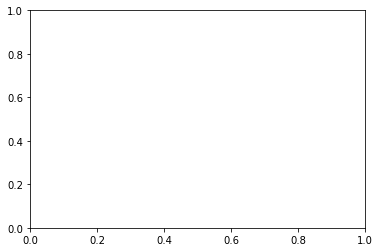

In [16]:
plt.plot(STRAINS[0][0],STRAINS[0][1])

In [85]:
print(len(STRAINS[0][0]))
print(len(STRAINS[0][NUM_TIMEPOINTS-1]))

328360
206591


In [100]:
Y = np.array([1,2,4,5,6])
N = np.array([2,2,3,34,65,6,6,2])


N = N[np.where(Y==Y)]
N
type(FILTERED)

AttributeError: 'list' object has no attribute 'toarray'

In [17]:
len(STRAINS[0][0])

328360

In [18]:
len(STRAINS[0][NUM_TIMEPOINTS-1])

206591

In [19]:
FILTER = cp.deepcopy(STRAINS)



In [23]:
for i in range(NUM_TIMEPOINTS):
    
    FILTER = cp.deepcopy(STRAINS[0][i])
    print(np.shape(FILTER))
    #FILTER = FILTER[np.where(STRAINS[0][NUM_TIMEPOINTS-1]==STRAINS[0][NUM_TIMEPOINTS-1])]
    
    
    

(328360,)
(307529,)
(222430,)
(166030,)
(120475,)
(206591,)


In [ ]:
""" Because of this, I can't make the above assumption. It doesnt make sense for the final timepoint 
to have more barcodes than the previous two timepoints. """

## Barcode distributions across time

143575

ValueError: x and y must have same first dimension, but have shapes (328360,) and (307529,)

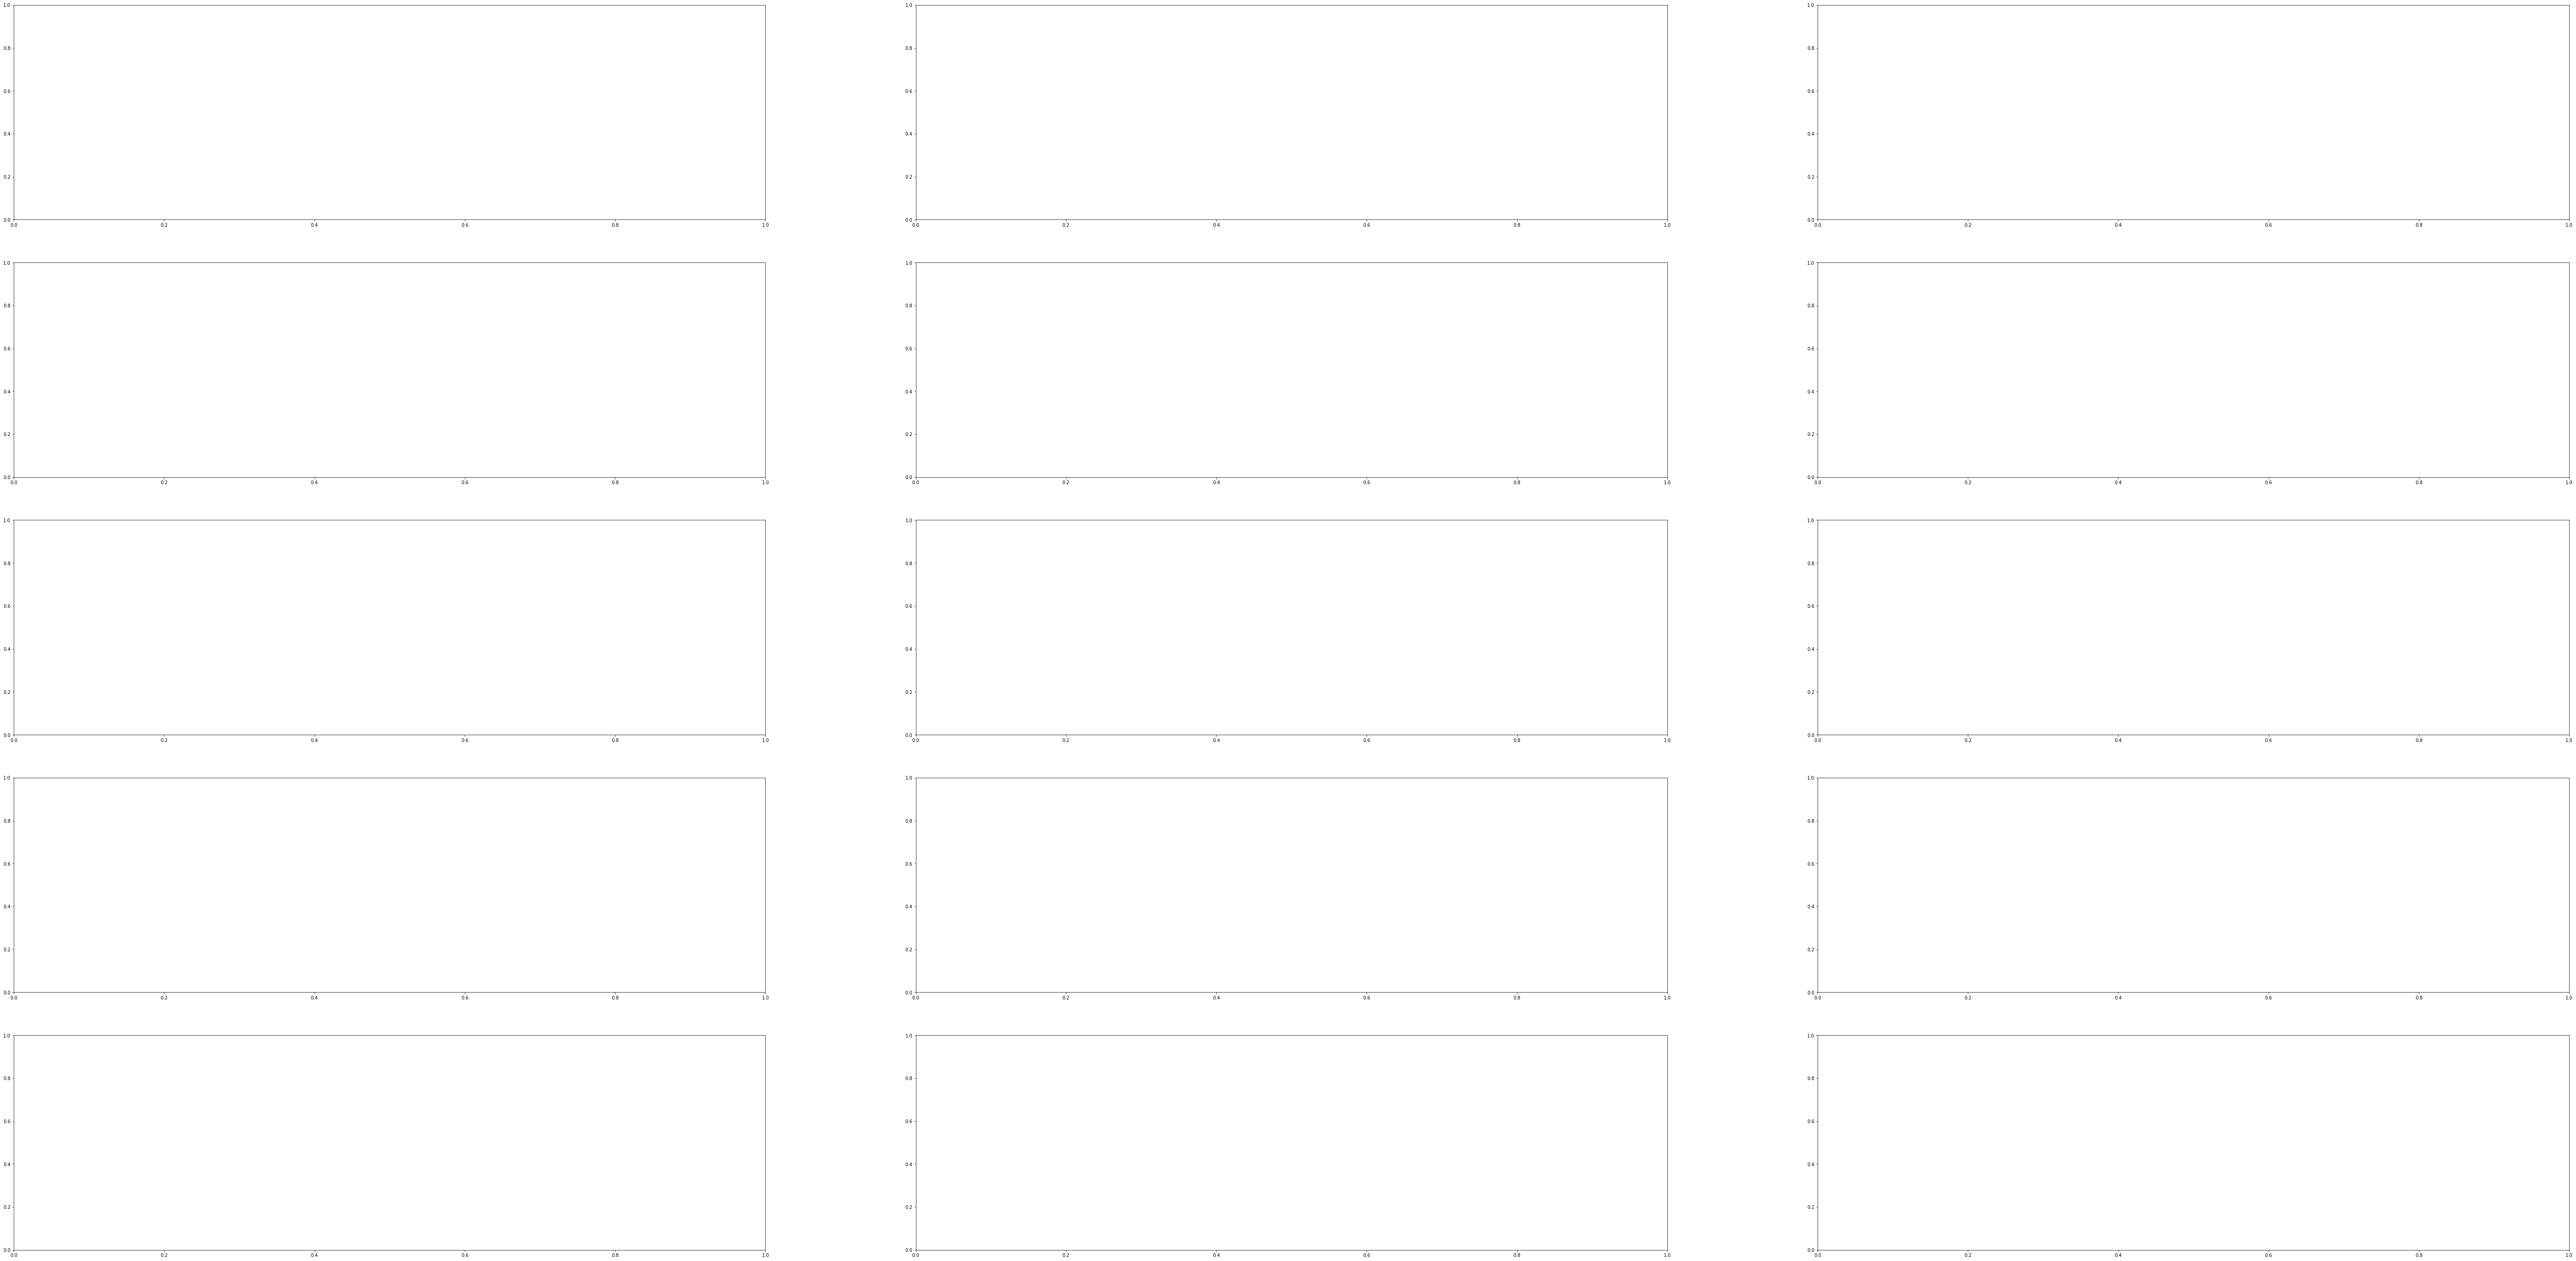

In [64]:
figure, ax = plt.subplots(NUM_TIMEPOINTS-1, NUM_STRAINS,figsize=(100,50))

for i in range(NUM_STRAINS):
    for j in range(NUM_TIMEPOINTS-1):
        
        ax[i,j].plot(STRAINS[i][j],STRAINS[i][j+1])
        
        


